# Perform ARIMA analysis on the data

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.ticker import MultipleLocator
from scipy.stats import boxcox

- Let us work with PD here for simplicity. 

In [58]:
data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)
data.columns = ["JD", "sind"]
data["year"] = Time(data["JD"].to_numpy(), format='jd', scale='tdb').jyear
data


C:\Users\Joey\AppData\Local\Temp\ipykernel_46784\3218693472.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)


,JD,sind,year
0,2439370.857,0.173873,1966.669013
1,2439371.843,0.175041,1966.671713
2,2439372.830,0.174457,1966.674415
3,2439392.845,0.175236,1966.729213
4,2439393.831,0.175918,1966.731912
...,...,...,...
1686,2448495.208,0.181948,1991.650125
1687,2448497.208,0.177421,1991.655600
1688,2448498.208,0.179252,1991.658338
1689,2448499.208,0.179312,1991.661076


In [59]:
dataset_length = len(data)
train_split = 0.7
valid_split = 0.15
# test_split = 1 - train_split - valid_split

train_idx = round(train_split*dataset_length)
valid_idx = round((valid_split + train_split) * dataset_length)

train_df = data.iloc[:train_idx]
valid_df = data.iloc[train_idx:valid_idx]
test_df  = data.iloc[valid_idx:]

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(1184, 3)
(253, 3)
(254, 3)


- Now we want to check for stationarity to make sure the ARIMA model is applicable.
- Let us examine the training dataset to prevent data leakage.

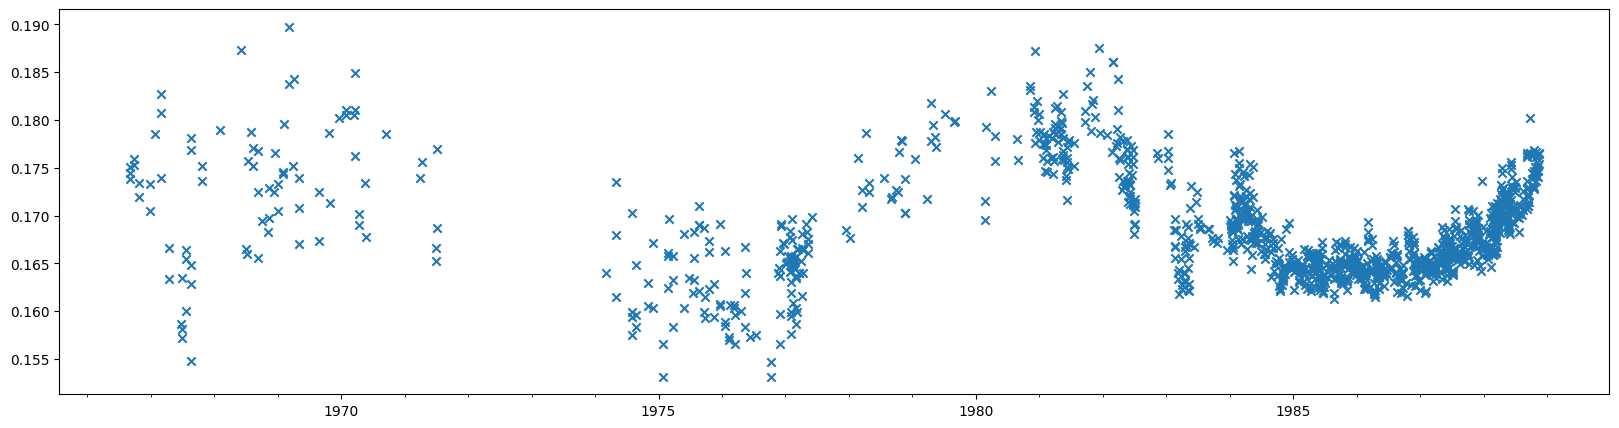

In [60]:
fig, ax = plt.subplots(figsize=(20,5))
plt.scatter(train_df["year"], train_df['sind'], marker='x')
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

- Looks vaguely sinusoidal
- Peaks at 1970ish and 1981ish
- Troughs at 1976ish and 1986ish
- This corresponds to the roughly 10 to 11 year solar cycle

----

- The variance of the data does not look constant
- We can check the mean of the data by checking the average values at the minima we have observed

In [61]:
trough1976 = data[data['year'].between(1975,1977)]
trough1986 = data[data['year'].between(1985,1987)]
mean1976 = trough1976['sind'].mean()
mean1986 = trough1986['sind'].mean()
mean_delta = abs(mean1976-mean1986)
data_range = data['sind'].max() - data['sind'].min()
print(f"The change in means is {mean_delta} out of overall range delta {data_range}")
print(f'Percentage {100*mean_delta/data_range:.2f}%')


The change in means is 0.0019412766020864003 out of overall range delta 0.03818200000000002
Percentage 5.08%


- This seems similar enough considering the uncertainty in the estimating the trough.
- Now how to fix the variance.
- No idea how the variance varies so use a Box-Cox transform to normalise.

,JD,sind,year,sind_norm
0,2439370.857,0.173873,1966.669013,-126.071612
1,2439371.843,0.175041,1966.671713,-123.162667
2,2439372.830,0.174457,1966.674415,-124.606236
3,2439392.845,0.175236,1966.729213,-122.685440
4,2439393.831,0.175918,1966.731912,-121.034936
...,...,...,...,...
1686,2448495.208,0.181948,1991.650125,-107.612873
1687,2448497.208,0.177421,1991.655600,-117.496992
1688,2448498.208,0.179252,1991.658338,-113.364349
1689,2448499.208,0.179312,1991.661076,-113.232110


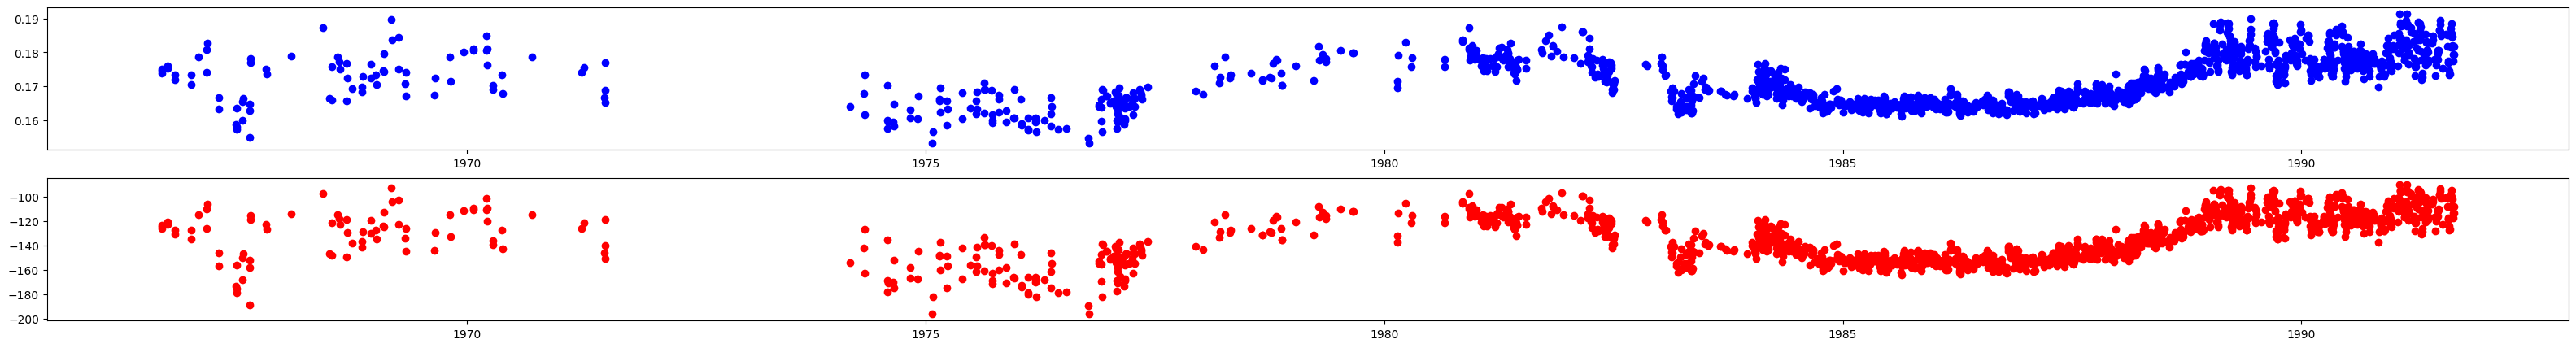

In [74]:
data['sind_norm'], lambda_ = boxcox(data['sind']) 
fig, ax = s=plt.subplots(2,1 ,figsize=(40,5))
ax[0].scatter(data['year'], data['sind'], color = 'blue')
ax[1].scatter(data['year'], data['sind_norm'], color = 'red')
data

- Now let's plot the ACF.